# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Malfino Muhammad Willianz | 5054251028 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

sns.set_style('whitegrid')
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Shape:', df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

Dataset terdiri dari 7.043 baris dan 21 kolom: `customerID`, target `Churn` (Yes/No), serta 19 fitur yang menggambarkan profil pelanggan perusahaan telekomunikasi. Fitur-fiturnya meliputi data demografis (`gender`, `SeniorCitizen`, `Partner`, `Dependents`), layanan yang digunakan (`PhoneService`, `InternetService`, `OnlineSecurity`, `StreamingTV`, dll), serta informasi akun (`tenure`, `Contract`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`). Hanya 3 kolom yang terbaca sebagai numerik; `TotalCharges` seharusnya numerik namun terbaca sebagai string, yang menandakan adanya nilai yang tidak valid.

## Stats

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [4]:
df.select_dtypes(exclude='number').describe().T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


`tenure` berkisar 0–72 bulan (median 29) dan `MonthlyCharges` berkisar 18,25–118,75. `SeniorCitizen` sebenarnya fitur biner (0/1) dengan hanya ±16% pelanggan lanjut usia. Pada fitur kategorikal, sebagian besar memiliki 2–3 kategori, kecuali `PaymentMethod` (4 kategori). Fitur layanan tambahan (`OnlineSecurity`, `TechSupport`, dll) memiliki kategori ketiga `No internet service`, sedangkan `MultipleLines` memiliki `No phone service`. `customerID` unik untuk setiap baris sehingga tidak berguna sebagai fitur. `TotalCharges` memiliki 6.531 nilai unik dengan nilai yang paling sering muncul (11 kali) adalah `20.2`.

## Missing Value dan Duplikat

In [5]:
print('Total missing value (NaN):', df.isna().sum().sum())
print('Jumlah baris duplikat     :', df.duplicated().sum())
print('Jumlah customerID duplikat:', df['customerID'].duplicated().sum())
print()

# TotalCharges bertipe object, cek nilai yang tidak bisa dikonversi ke angka
total_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
invalid = df[total_numeric.isna()]
print('Jumlah TotalCharges yang bukan angka:', len(invalid))
invalid[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Total missing value (NaN): 0
Jumlah baris duplikat     : 0
Jumlah customerID duplikat: 0

Jumlah TotalCharges yang bukan angka: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Tidak ada NaN maupun duplikat, namun terdapat **11 nilai `TotalCharges` berupa spasi kosong** (`' '`), yang menjadi alasan kolom ini terbaca sebagai string. Seluruh 11 baris tersebut memiliki `tenure = 0`, yaitu pelanggan yang baru bergabung dan belum melewati satu periode penagihan, sehingga nilai `TotalCharges` yang logis adalah 0.

## Target

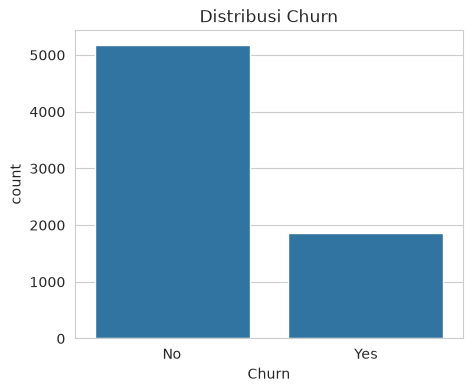

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribusi Churn')
plt.show()

print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Distribusi target **imbalanced**: 5.174 pelanggan tidak churn (73,46%) dan 1.869 pelanggan churn (26,54%), dengan rasio sekitar 2,8:1. Model yang selalu memprediksi "No" sudah mencapai akurasi ±73,5%, sehingga angka ini menjadi baseline. Karena tujuan bisnisnya adalah mendeteksi pelanggan yang akan berhenti berlangganan, precision, recall, dan F1-score pada kelas churn juga perlu dipantau selain accuracy.

## Distribusi Fitur Numerik per Kelas

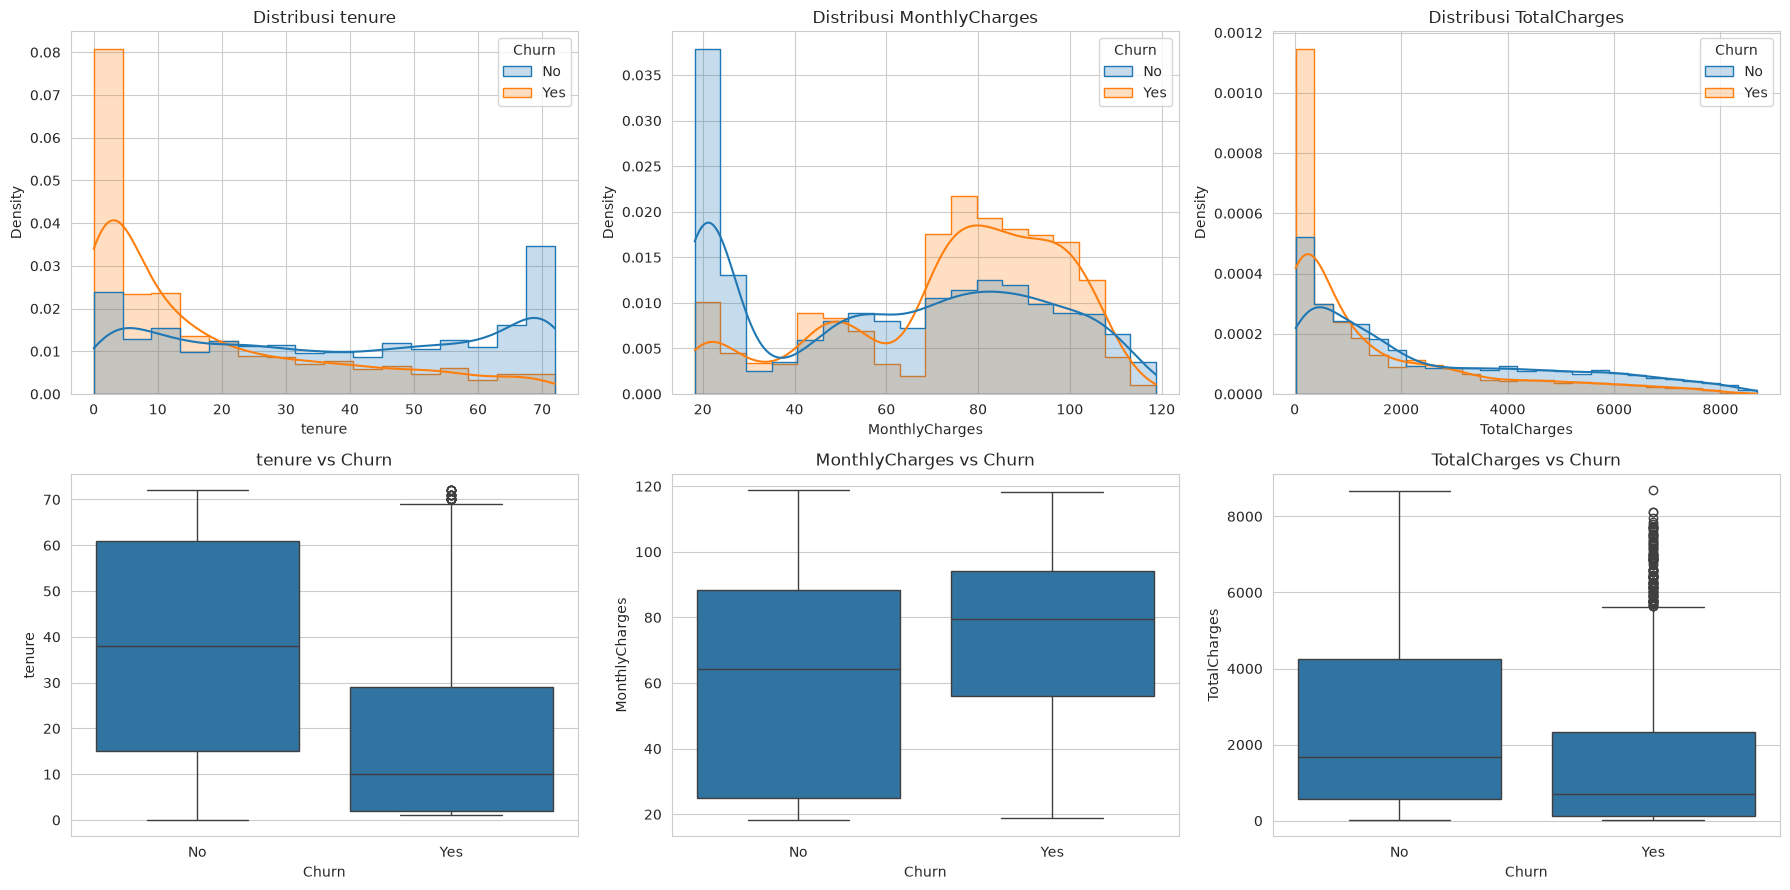

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.425,1683.60
Yes,10.0,79.650,703.55


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, element='step', stat='density', common_norm=False, ax=axes[0, i])
    axes[0, i].set_title(f'Distribusi {col}')
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[1, i])
    axes[1, i].set_title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

df.groupby('Churn')[num_cols].median()

Ketiga fitur numerik menunjukkan perbedaan yang jelas antar kelas:
- **`tenure`**: pelanggan churn memiliki tenure jauh lebih pendek (median 10 vs 38 bulan). Distribusi churn sangat menumpuk di bulan-bulan awal, artinya pelanggan paling rawan berhenti di awal masa berlangganan.
- **`MonthlyCharges`**: pelanggan churn cenderung membayar lebih mahal per bulan (median 79,65 vs 64,43), dengan puncak distribusi di rentang 70–105.
- **`TotalCharges`**: pelanggan churn memiliki total tagihan lebih kecil (median 703,55 vs 1.683,60), yang merupakan efek dari tenure yang pendek.

Ketiga fitur memiliki skala yang sangat berbeda (tenure maksimal 72, sedangkan TotalCharges hingga ±8.700), dan `TotalCharges` sangat right-skewed.

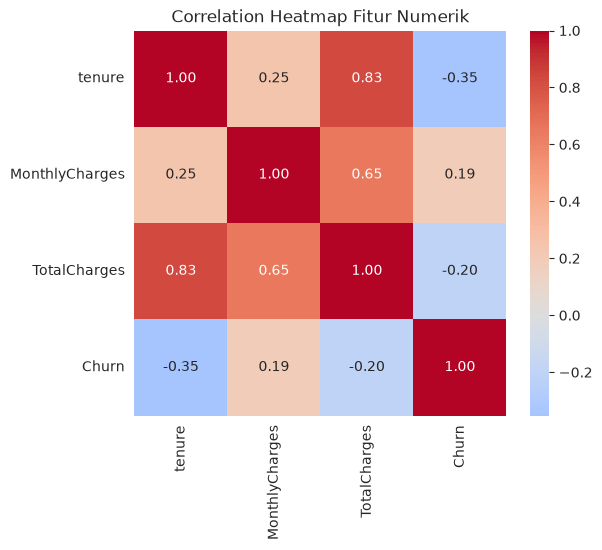

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].assign(Churn=(df['Churn'] == 'Yes').astype(int)).corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap Fitur Numerik')
plt.show()

`TotalCharges` berkorelasi tinggi dengan `tenure` (r ≈ 0,83) dan `MonthlyCharges` (r ≈ 0,65), karena secara konsep TotalCharges ≈ tenure × MonthlyCharges. Terhadap target, `tenure` memiliki korelasi negatif terkuat (r ≈ -0,35), sedangkan `MonthlyCharges` berkorelasi positif (r ≈ 0,19).

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

### Churn Rate per Fitur Kategorikal

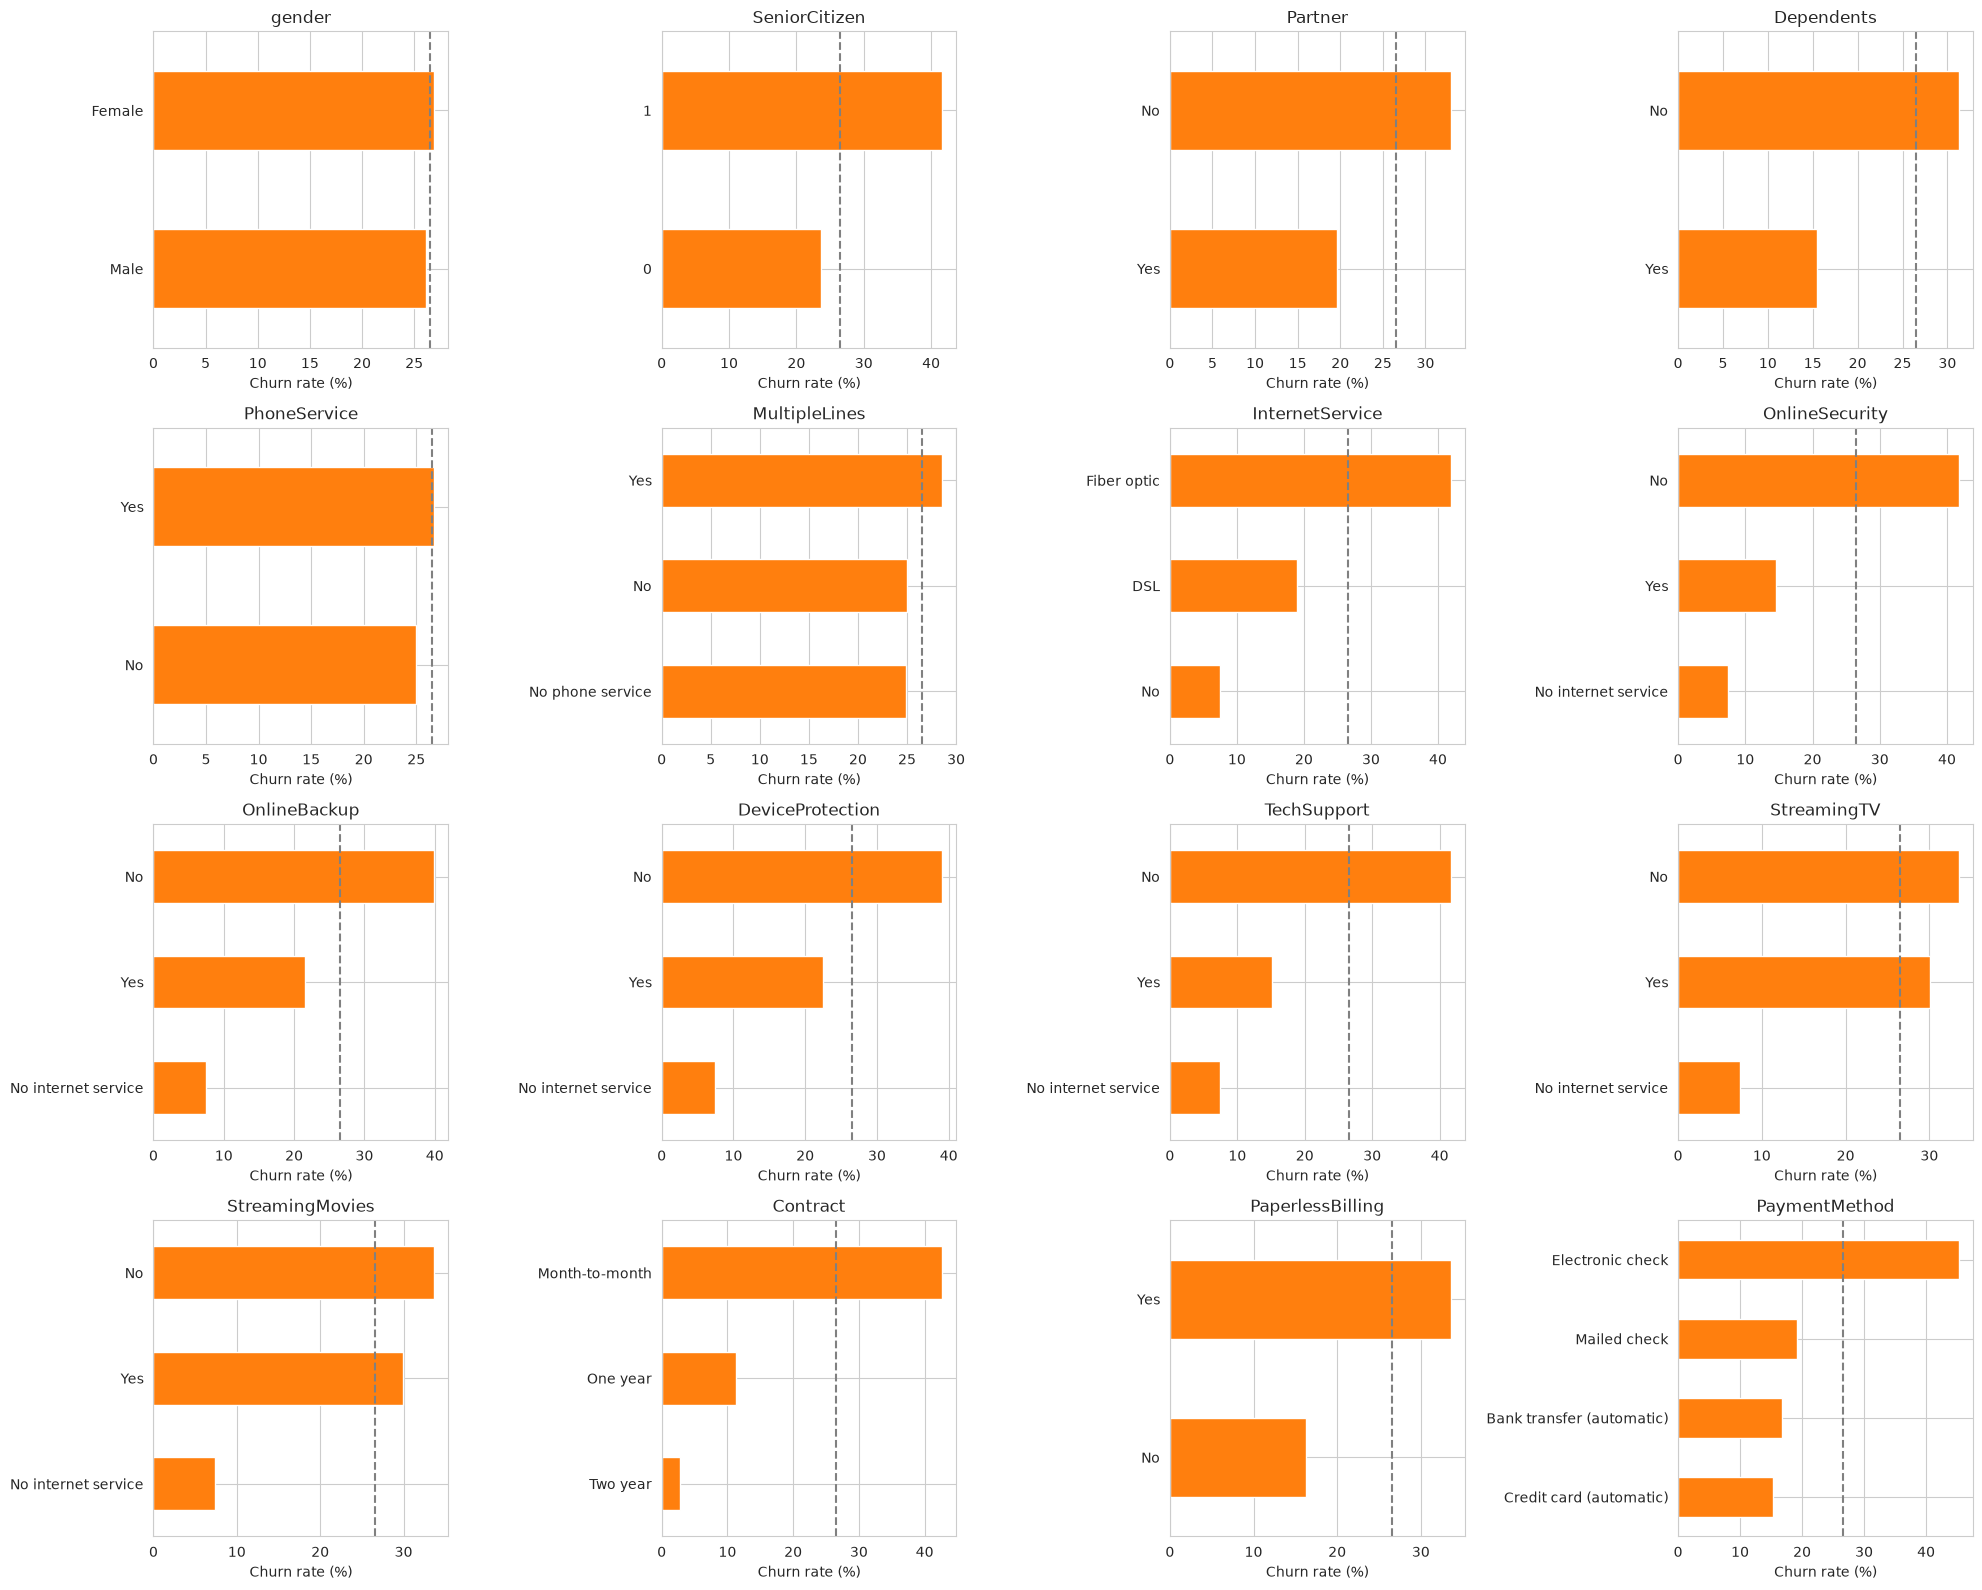

In [9]:
cat_cols = df.columns.drop(['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']).tolist()

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for ax, col in zip(axes.flatten(), cat_cols):
    rate = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).sort_values()
    rate.plot.barh(ax=ax, color='tab:orange')
    ax.axvline((df['Churn'] == 'Yes').mean() * 100, linestyle='--', color='gray')
    ax.set_title(col)
    ax.set_xlabel('Churn rate (%)')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

Garis putus-putus menunjukkan churn rate keseluruhan (26,54%). Beberapa kelompok pelanggan memiliki churn rate yang jauh di atas rata-rata, yaitu pelanggan dengan kontrak `Month-to-month` (42,71%), metode pembayaran `Electronic check` (45,29%), internet `Fiber optic` (41,89%), serta pelanggan yang **tidak** berlangganan `OnlineSecurity` atau `TechSupport` (±42%). Sebaliknya, pelanggan tanpa layanan internet memiliki churn rate sangat rendah (7,40%). Fitur `gender`, `PhoneService`, dan `MultipleLines` hampir tidak memengaruhi churn rate.

In [10]:
churn_rate = []
for col in cat_cols:
    rate = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)
    churn_rate.append({'Fitur': col, 'Min Churn Rate (%)': rate.min(), 'Max Churn Rate (%)': rate.max(),
                       'Selisih': rate.max() - rate.min()})

pd.DataFrame(churn_rate).set_index('Fitur').sort_values('Selisih', ascending=False).round(2)

,Min Churn Rate (%),Max Churn Rate (%),Selisih
Fitur,,,
Contract,2.83,42.71,39.88
InternetService,7.40,41.89,34.49
OnlineSecurity,7.40,41.77,34.36
TechSupport,7.40,41.64,34.23
OnlineBackup,7.40,39.93,32.52
DeviceProtection,7.40,39.13,31.72
PaymentMethod,15.24,45.29,30.04
StreamingMovies,7.40,33.68,26.28
StreamingTV,7.40,33.52,26.12


Tabel di atas mengurutkan fitur kategorikal berdasarkan selisih churn rate tertinggi dan terendah antar kategorinya. `Contract` menjadi fitur paling diskriminatif (selisih 39,88%, dari 2,83% hingga 42,71%), diikuti `InternetService`, `OnlineSecurity`, dan `TechSupport`. `gender` memiliki selisih hanya 0,76% sehingga hampir tidak informatif. Fitur ini tetap disertakan karena ANN dapat belajar sendiri untuk memberikan bobot kecil pada fitur yang tidak relevan.

### Tenure per Jenis Kontrak

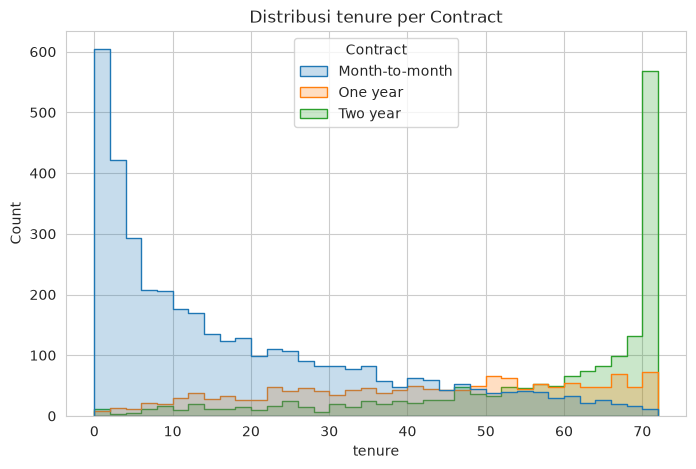

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Contract', element='step', bins=36)
plt.title('Distribusi tenure per Contract')
plt.show()

pd.crosstab(df['Contract'], df['Churn'], normalize='index').round(4) * 100

Pelanggan dengan kontrak `Month-to-month` didominasi tenure pendek, sedangkan kontrak `Two year` didominasi tenure panjang (banyak yang sudah mencapai 72 bulan). Churn rate turun drastis seiring durasi kontrak: 42,71% (bulanan), 11,27% (1 tahun), dan hanya 2,83% (2 tahun). Hal ini menunjukkan bahwa `Contract` dan `tenure` saling berkaitan, dan kombinasi keduanya merupakan sinyal utama churn. Pola interaksi antar fitur seperti ini merupakan hal yang dapat dimanfaatkan oleh ANN melalui hidden layer.

# 2. Preprocessing

In [12]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# 11 nilai TotalCharges kosong semuanya pelanggan dengan tenure = 0 (baru bergabung, belum pernah ditagih),
# sehingga diisi 0. Nilai ini berasal dari logika bisnis, bukan statistik data, sehingga aman dari data leakage.
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop(columns=['customerID'])

print('Total missing value:', df.isna().sum().sum())

Total missing value: 0


In [13]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Fitur biner (Yes/No, Male/Female) -> 0/1
binary_cols = [col for col in cat_cols if df[col].nunique() == 2 and col != 'SeniorCitizen']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Fitur dengan > 2 kategori -> One-Hot Encoding (tidak memiliki urutan yang jelas)
multi_cols = [col for col in cat_cols if df[col].nunique() > 2]
df = pd.get_dummies(df, columns=multi_cols, drop_first=True, dtype=int)

print('Fitur biner   :', binary_cols)
print('Fitur One-Hot :', multi_cols)
print('Shape setelah encoding:', df.shape)

Fitur biner   : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Fitur One-Hot : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Shape setelah encoding: (7043, 31)


In [14]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train shape: (5634, 30)
Test shape : (1409, 30)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [15]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
# Hanya fitur numerik kontinu yang di-scaling; fitur hasil encoding sudah berada pada rentang 0/1
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled[num_cols].describe().loc[['mean', 'std', 'min', 'max']].round(3)

,tenure,MonthlyCharges,TotalCharges
mean,-0.000,-0.000,0.000
std,1.000,1.000,1.000
min,-1.322,-1.544,-1.009
max,1.608,1.786,2.802


Preprocessing yang dilakukan:

| Tahap | Keputusan |
|---|---|
| Missing value | 11 `TotalCharges` kosong (semua `tenure = 0`) diisi 0, berdasarkan logika bisnis sehingga tidak ada data leakage |
| Kolom tidak relevan | `customerID` dibuang |
| Encoding biner | `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, dan target `Churn` di-map ke 0/1 |
| One-Hot Encoding | 10 fitur dengan > 2 kategori (`Contract`, `PaymentMethod`, `InternetService`, dll) dengan `drop_first=True` untuk menghindari kolom yang redundan |
| Split | 80:20 dengan `stratify=y` → 5.634 train, 1.409 test (proporsi churn ±26,5% di keduanya) |
| Scaling | `StandardScaler` hanya pada `tenure`, `MonthlyCharges`, dan `TotalCharges`, di-fit pada train set saja |

Setelah encoding, data memiliki 30 fitur. Fitur hasil encoding tidak di-scaling karena sudah berada pada rentang 0–1 yang sebanding dengan fitur numerik yang telah distandarisasi (rentang ±-1,5 s.d. 2,8).

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [16]:
ann_base = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=500, random_state=42)
ann_base.fit(X_train_scaled, y_train)

print('Jumlah iterasi :', ann_base.n_iter_)
print('Loss akhir     :', round(ann_base.loss_, 4))
print('Train accuracy :', round(accuracy_score(y_train, ann_base.predict(X_train_scaled)), 4))

Jumlah iterasi : 271
Loss akhir     : 0.3925
Train accuracy : 0.8159


In [17]:
base_predictions = ann_base.predict(X_test_scaled)
print('Test accuracy  :', round(accuracy_score(y_test, base_predictions), 4))

Test accuracy  : 0.7906


Model baseline (`hidden_layer_sizes=(10,)`, ReLU, solver default `adam`) berhenti di iterasi ke-271 sebelum mencapai `max_iter=500`, karena loss training sudah tidak membaik lebih dari `tol` selama 10 iterasi berturut-turut. Model mencapai train accuracy 81,59% dan test accuracy 79,06%, sekitar 5,6% di atas baseline "selalu prediksi No" (73,46%). Gap train-test yang kecil (±2,5%) menunjukkan model belum overfitting.

## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [18]:
activations = ['relu', 'tanh', 'logistic']

act_models = {}
for act in activations:
    model = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    act_models[act] = model

In [19]:
results = []
for act, model in act_models.items():
    test_pred = model.predict(X_test_scaled)
    results.append({
        'Activation': act,
        'Train Accuracy': accuracy_score(y_train, model.predict(X_train_scaled)),
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Test F1': f1_score(y_test, test_pred),
        'Iterasi': model.n_iter_,
        'Loss Akhir': model.loss_,
    })

act_results = pd.DataFrame(results).set_index('Activation')
act_results

,Train Accuracy,Test Accuracy,Test F1,Iterasi,Loss Akhir
Activation,,,,,
relu,0.815939,0.790632,0.555053,271,0.392496
tanh,0.818069,0.797729,0.577778,273,0.395385
logistic,0.806354,0.797729,0.582723,161,0.410698


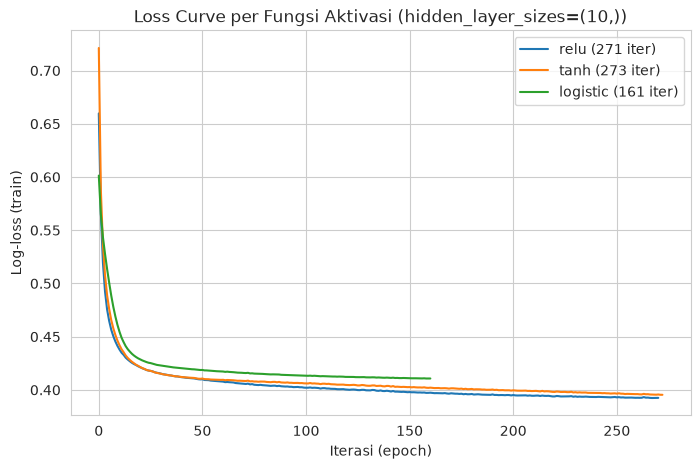

In [20]:
plt.figure(figsize=(8, 5))
for act, model in act_models.items():
    plt.plot(model.loss_curve_, label=f'{act} ({model.n_iter_} iter)')
plt.title('Loss Curve per Fungsi Aktivasi (hidden_layer_sizes=(10,))')
plt.xlabel('Iterasi (epoch)')
plt.ylabel('Log-loss (train)')
plt.legend()
plt.show()

In [21]:
# Cek stabilitas: ulangi dengan beberapa random_state (inisialisasi bobot berbeda)
seed_results = []
for act in activations:
    for seed in range(5):
        model = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=500, random_state=seed)
        model.fit(X_train_scaled, y_train)
        seed_results.append({'Activation': act, 'seed': seed,
                             'Test Accuracy': accuracy_score(y_test, model.predict(X_test_scaled))})

pd.DataFrame(seed_results).groupby('Activation')['Test Accuracy'].agg(['mean', 'std', 'min', 'max'])

,mean,std,min,max
Activation,,,,
logistic,0.798864,0.001289,0.797019,0.800568
relu,0.792051,0.003367,0.787083,0.796309
tanh,0.795742,0.004665,0.792051,0.802697


Hasil ketiga fungsi aktivasi dengan arsitektur yang sama `(10,)`:

| Activation | Test Accuracy | Test F1 | Iterasi | Rata-rata Test Acc (5 seed) |
|---|---|---|---|---|
| ReLU | 0.7906 | 0.5551 | 271 | 0.7921 ± 0.0034 |
| Tanh | 0.7977 | 0.5778 | 273 | 0.7957 ± 0.0047 |
| Logistic | 0.7977 | 0.5827 | 161 | **0.7989 ± 0.0013** |

Ketiga fungsi aktivasi menghasilkan test accuracy yang sangat mirip (selisih maksimal 0,7%, atau sekitar 10 sampel dari 1.409). Logistic dan Tanh memiliki test accuracy yang sama, namun **Logistic dipilih** karena F1 kelas churn sedikit lebih tinggi, rata-rata akurasinya paling tinggi pada 5 random seed berbeda, serta variansinya paling kecil (std 0,0013), sehingga hasilnya paling stabil terhadap inisialisasi bobot.

Pada loss curve, ReLU dan Tanh mencapai training loss yang lebih rendah (±0,39) dibanding Logistic (±0,41), namun hal ini tidak berdampak pada test accuracy, yang mengindikasikan sebagian penurunan loss pada ReLU/Tanh berasal dari pola yang spesifik terhadap data train. Logistic berhenti lebih cepat (161 iterasi) karena gradien sigmoid lebih kecil (maksimal 0,25), sehingga perubahan loss per iterasi cepat jatuh di bawah `tol`.

## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [22]:
architectures = [(2,), (5,), (10,), (50,), (100,), (100, 50), (200, 100, 50)]
best_activation = 'logistic'  # dipilih berdasarkan hasil eksperimen 3.2

arch_models = {}
for arch in architectures:
    model = MLPClassifier(hidden_layer_sizes=arch, activation=best_activation, max_iter=500, random_state=42)
    model.fit(X_train_scaled, y_train)
    arch_models[arch] = model

In [23]:
results = []
for arch, model in arch_models.items():
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    results.append({
        'Arsitektur': str(arch),
        'Jumlah Parameter': sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_),
        'Train Accuracy': accuracy_score(y_train, train_pred),
        'Test Accuracy': accuracy_score(y_test, test_pred),
        'Train F1': f1_score(y_train, train_pred),
        'Test F1': f1_score(y_test, test_pred),
        'Iterasi': model.n_iter_,
    })

arch_results = pd.DataFrame(results).set_index('Arsitektur')
arch_results

,Jumlah Parameter,Train Accuracy,Test Accuracy,Train F1,Test F1,Iterasi
Arsitektur,,,,,,
"(2,)",65,0.801917,0.797019,0.602281,0.594901,155
"(5,)",161,0.807774,0.799858,0.605464,0.590116,211
"(10,)",321,0.806354,0.797729,0.600805,0.582723,161
"(50,)",1601,0.808129,0.806246,0.607052,0.600293,154
"(100,)",3201,0.806354,0.802697,0.603128,0.594752,110
"(100, 50)",8201,0.806709,0.804116,0.602410,0.597668,115
"(200, 100, 50)",31401,0.805644,0.803407,0.573432,0.569207,78


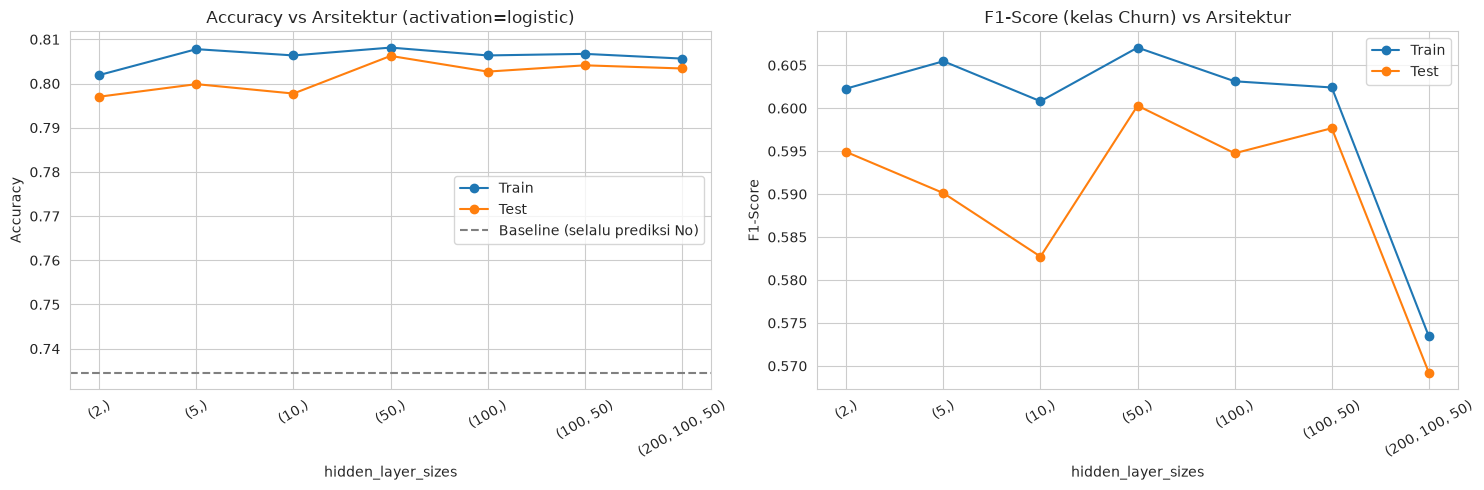

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(arch_results.index, arch_results['Train Accuracy'], marker='o', label='Train')
axes[0].plot(arch_results.index, arch_results['Test Accuracy'], marker='o', label='Test')
axes[0].axhline(1 - y_test.mean(), linestyle='--', color='gray', label='Baseline (selalu prediksi No)')
axes[0].set_title(f'Accuracy vs Arsitektur (activation={best_activation})')
axes[0].set_xlabel('hidden_layer_sizes')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(arch_results.index, arch_results['Train F1'], marker='o', label='Train')
axes[1].plot(arch_results.index, arch_results['Test F1'], marker='o', label='Test')
axes[1].set_title('F1-Score (kelas Churn) vs Arsitektur')
axes[1].set_xlabel('hidden_layer_sizes')
axes[1].set_ylabel('F1-Score')
axes[1].legend()

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Dengan pengaturan default (berhenti otomatis saat loss stagnan), **tidak terlihat gejala overfitting yang jelas**: train accuracy seluruh arsitektur berada di kisaran 80,2–80,8%, dan test accuracy di kisaran 79,7–80,6% meskipun jumlah parameter meningkat hampir 500 kali lipat (65 → 31.401). Test accuracy terbaik dicapai oleh `(50,)` (80,62%, F1 0,6003). Hal ini karena arsitektur besar justru berhenti lebih cepat (78 iterasi pada `(200, 100, 50)` vs 155 iterasi pada `(2,)`), sehingga belum sempat menghafal data train. Satu-satunya tanda awal terlihat pada model terbesar `(200, 100, 50)`, yang memiliki test F1 terendah (0,5692) meskipun accuracy-nya masih tinggi.

### Training Tanpa Early Stop (Dipaksa hingga max_iter)

Secara default, `MLPClassifier` berhenti otomatis jika loss training tidak membaik lebih dari `tol` selama 10 iterasi (`n_iter_no_change=10`), sehingga model besar sering berhenti sebelum sempat menghafal data. Untuk melihat kapasitas sebenarnya dari setiap arsitektur, eksperimen diulang dengan `max_iter=1000` dan berhenti otomatis dinonaktifkan.

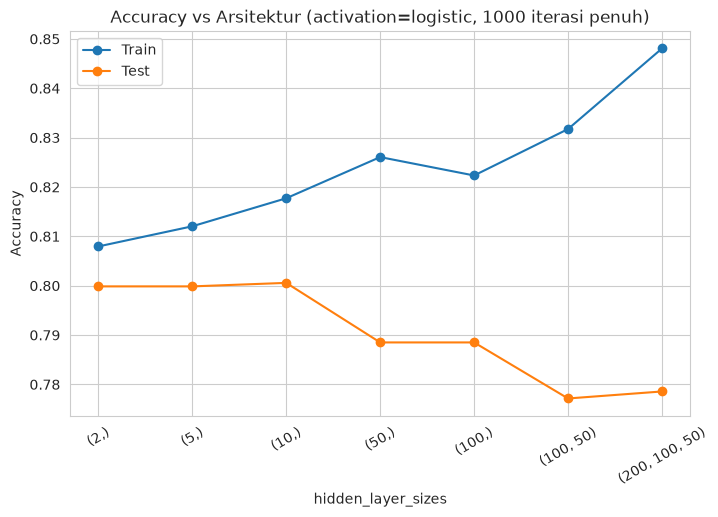

,Train Accuracy,Test Accuracy,Loss Akhir
Arsitektur,,,
"(2,)",0.807952,0.799858,0.408080
"(5,)",0.812034,0.799858,0.401030
"(10,)",0.817714,0.800568,0.391500
"(50,)",0.826056,0.788502,0.379689
"(100,)",0.822329,0.788502,0.379041
"(100, 50)",0.831736,0.777147,0.364938
"(200, 100, 50)",0.848065,0.778566,0.318146


In [25]:
results = []
for arch in architectures:
    model = MLPClassifier(hidden_layer_sizes=arch, activation=best_activation, max_iter=1000,
                          n_iter_no_change=1001, random_state=42)
    model.fit(X_train_scaled, y_train)
    results.append({
        'Arsitektur': str(arch),
        'Train Accuracy': accuracy_score(y_train, model.predict(X_train_scaled)),
        'Test Accuracy': accuracy_score(y_test, model.predict(X_test_scaled)),
        'Loss Akhir': model.loss_,
    })

forced_results = pd.DataFrame(results).set_index('Arsitektur')

plt.figure(figsize=(8, 5))
plt.plot(forced_results.index, forced_results['Train Accuracy'], marker='o', label='Train')
plt.plot(forced_results.index, forced_results['Test Accuracy'], marker='o', label='Test')
plt.title(f'Accuracy vs Arsitektur (activation={best_activation}, 1000 iterasi penuh)')
plt.xlabel('hidden_layer_sizes')
plt.ylabel('Accuracy')
plt.xticks(rotation=30)
plt.legend()
plt.show()

forced_results

Ketika setiap model dipaksa berlatih selama 1000 iterasi penuh, pola overfitting menjadi sangat jelas. **Train accuracy terus naik** seiring bertambahnya ukuran arsitektur (80,80% → 84,81%), dan loss training turun dari 0,408 ke 0,318, sedangkan **test accuracy mencapai puncak pada `(10,)`** (80,06%) lalu menurun ke 78,85% pada `(50,)`/`(100,)` dan 77,71–77,86% pada arsitektur 2–3 hidden layer. Gap train-test melebar dari ±0,8% pada `(2,)` menjadi ±7% pada `(200, 100, 50)`. Artinya, gejala overfitting mulai muncul pada arsitektur **`(50,)`** ketika dilatih cukup lama, dan semakin parah pada arsitektur multi-layer.

### Pengaruh max_iter

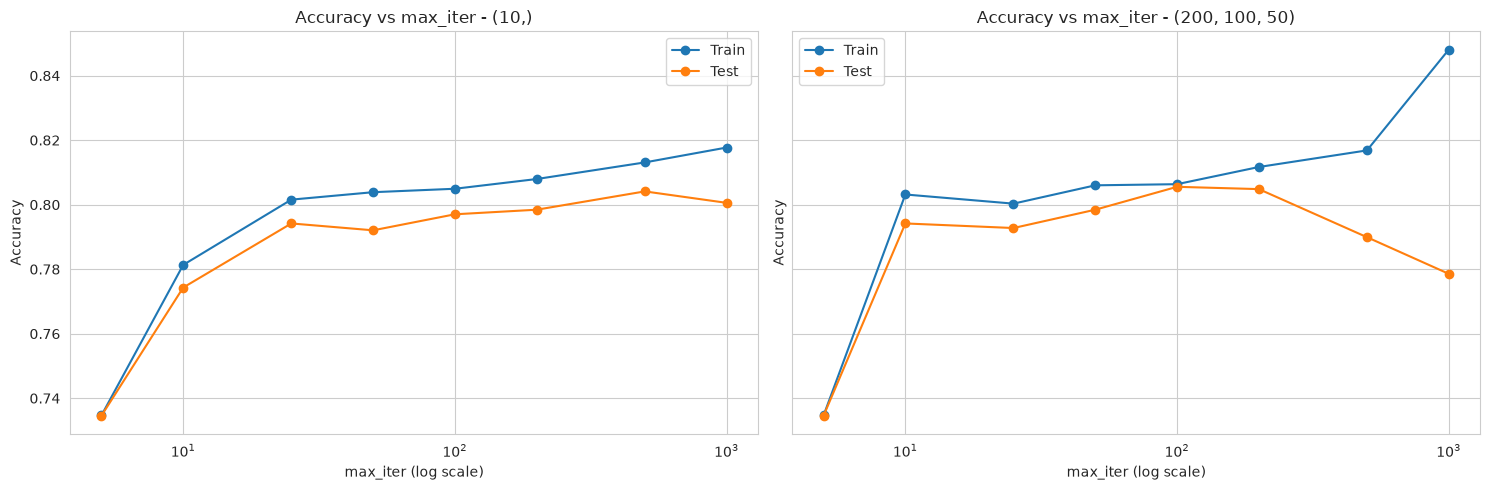

Train Accuracy                Test Accuracy               
Arsitektur          (10,) (200, 100, 50)         (10,) (200, 100, 50)
max_iter                                                             
5                  0.7346         0.7346        0.7346         0.7346
10                 0.7813         0.8032        0.7743         0.7942
25                 0.8016         0.8003        0.7942         0.7928
50                 0.8039         0.8060        0.7921         0.7984
100                0.8049         0.8064        0.7970         0.8055
200                0.8080         0.8117        0.7984         0.8048
500                0.8131         0.8168        0.8041         0.7899
1000               0.8177         0.8481        0.8006         0.7786

In [26]:
iters = [5, 10, 25, 50, 100, 200, 500, 1000]

results = []
for it in iters:
    for arch in [(10,), (200, 100, 50)]:
        model = MLPClassifier(hidden_layer_sizes=arch, activation=best_activation, max_iter=it,
                              random_state=42, n_iter_no_change=it + 1)  # tanpa berhenti otomatis
        model.fit(X_train_scaled, y_train)
        results.append({
            'max_iter': it, 'Arsitektur': str(arch),
            'Train Accuracy': accuracy_score(y_train, model.predict(X_train_scaled)),
            'Test Accuracy': accuracy_score(y_test, model.predict(X_test_scaled)),
        })

iter_results = pd.DataFrame(results).pivot(index='max_iter', columns='Arsitektur')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, arch in zip(axes, ['(10,)', '(200, 100, 50)']):
    ax.plot(iters, iter_results[('Train Accuracy', arch)], marker='o', label='Train')
    ax.plot(iters, iter_results[('Test Accuracy', arch)], marker='o', label='Test')
    ax.set_xscale('log')
    ax.set_title(f'Accuracy vs max_iter - {arch}')
    ax.set_xlabel('max_iter (log scale)')
    ax.set_ylabel('Accuracy')
    ax.legend()
plt.tight_layout()
plt.show()

iter_results.round(4)

Eksperimen `max_iter` memperlihatkan bahwa overfitting juga bergantung pada **lamanya training**:
- Pada `max_iter = 5`, kedua model masih underfitting dan hanya memprediksi kelas mayoritas (73,46% = baseline).
- Model kecil `(10,)` stabil: test accuracy bertahan di ±80% hingga 1000 iterasi dengan gap train-test yang tetap kecil (±1,7%), karena kapasitasnya yang terbatas tidak cukup untuk menghafal data.
- Model besar `(200, 100, 50)` mencapai test accuracy terbaik di sekitar **100 iterasi** (80,55%), setelah itu test accuracy menurun (78,99% pada 500 iterasi, 77,86% pada 1000 iterasi) sementara train accuracy terus naik hingga 84,81%.

Hal ini menunjukkan bahwa kombinasi **arsitektur besar dan training yang lama** adalah pemicu utama overfitting pada ANN.

# 4. Evaluasi Model

In [27]:
best_act_model = act_models['logistic']
best_arch = (50,)  # dipilih dari eksperimen arsitektur di atas
best_arch_model = arch_models[best_arch]
largest_model = arch_models[(200, 100, 50)]

models = {
    f'ANN {best_activation} (10,) [3.2]': best_act_model.predict(X_test_scaled),
    f'ANN {best_activation} {best_arch} [3.3]': best_arch_model.predict(X_test_scaled),
    f'ANN {best_activation} (200, 100, 50) [3.3, terbesar]': largest_model.predict(X_test_scaled),
}

scores = pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, p) for p in models.values()],
    'Precision': [precision_score(y_test, p) for p in models.values()],
    'Recall': [recall_score(y_test, p) for p in models.values()],
    'F1 Score': [f1_score(y_test, p) for p in models.values()],
}, index=list(models.keys()))

scores

,Accuracy,Precision,Recall,F1 Score
"ANN logistic (10,) [3.2]",0.797729,0.644013,0.532086,0.582723
"ANN logistic (50,) [3.3]",0.806246,0.663430,0.548128,0.600293
"ANN logistic (200, 100, 50) [3.3, terbesar]",0.803407,0.680297,0.489305,0.569207


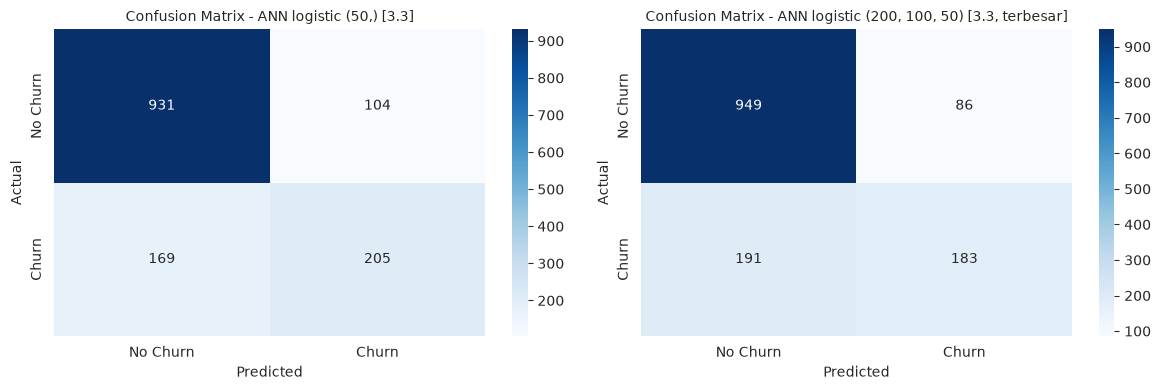

              precision    recall  f1-score   support

    No Churn     0.8464    0.8995    0.8721      1035
       Churn     0.6634    0.5481    0.6003       374

    accuracy                         0.8062      1409
   macro avg     0.7549    0.7238    0.7362      1409
weighted avg     0.7978    0.8062    0.8000      1409



In [28]:
best_name = f'ANN {best_activation} {best_arch} [3.3]'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name in zip(axes, [best_name, list(models)[2]]):
    cm = confusion_matrix(y_test, models[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'Confusion Matrix - {name}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

print(classification_report(y_test, models[best_name], target_names=['No Churn', 'Churn'], digits=4))

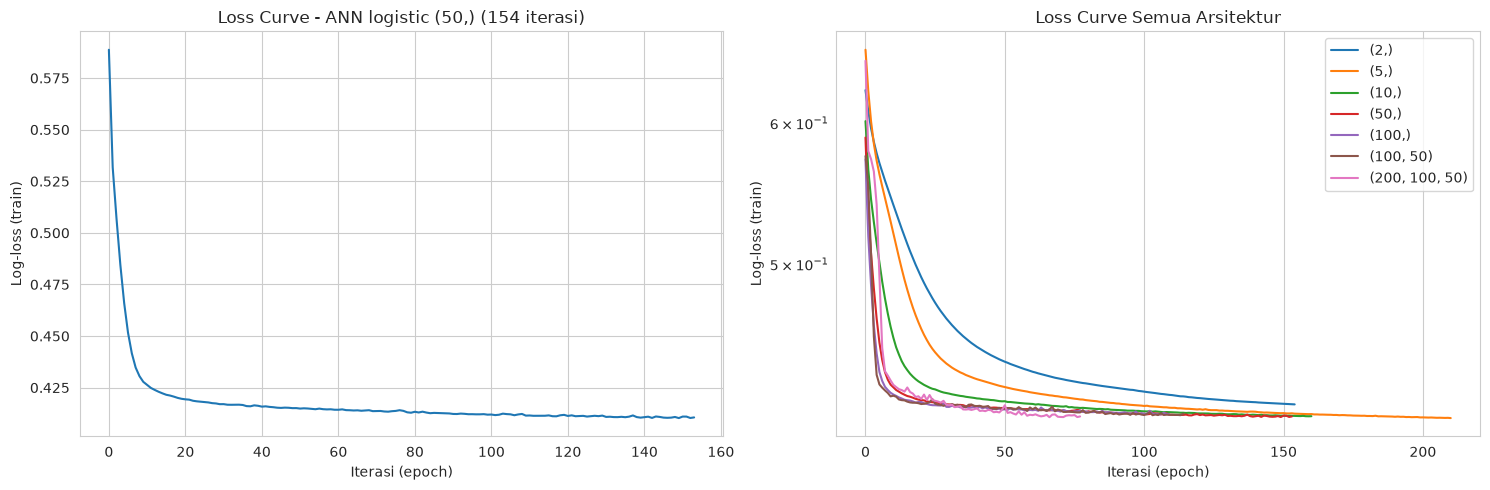

Iterasi: 154 | loss akhir: 0.4106 | perubahan loss 10 iterasi terakhir: 0.00045


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(best_arch_model.loss_curve_)
axes[0].set_title(f'Loss Curve - ANN {best_activation} {best_arch} ({best_arch_model.n_iter_} iterasi)')
axes[0].set_xlabel('Iterasi (epoch)')
axes[0].set_ylabel('Log-loss (train)')

for arch, model in arch_models.items():
    axes[1].plot(model.loss_curve_, label=str(arch))
axes[1].set_title('Loss Curve Semua Arsitektur')
axes[1].set_xlabel('Iterasi (epoch)')
axes[1].set_ylabel('Log-loss (train)')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Iterasi:', best_arch_model.n_iter_, '| loss akhir:', round(best_arch_model.loss_, 4),
      '| perubahan loss 10 iterasi terakhir:', round(best_arch_model.loss_curve_[-11] - best_arch_model.loss_curve_[-1], 5))

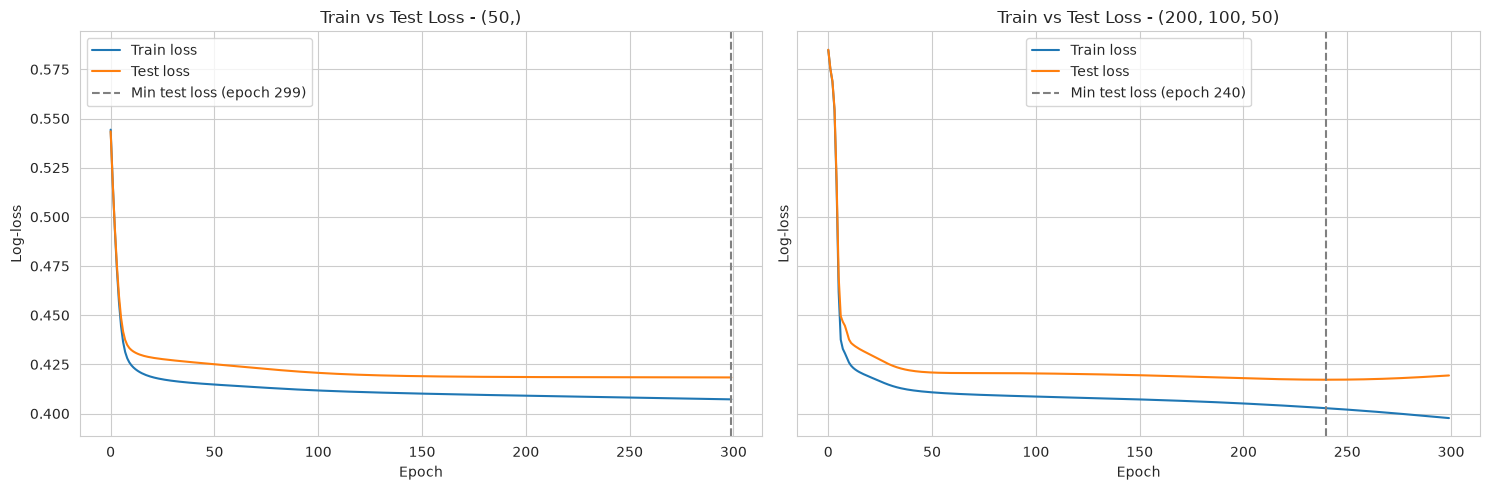

In [30]:
# Validation loss: bandingkan model terbaik dan model terbesar dengan memantau log-loss test di setiap epoch
from sklearn.metrics import log_loss

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, arch in zip(axes, [best_arch, (200, 100, 50)]):
    model = MLPClassifier(hidden_layer_sizes=arch, activation=best_activation, random_state=42)
    train_loss, test_loss = [], []
    for epoch in range(300):
        model.partial_fit(X_train_scaled, y_train, classes=[0, 1])
        train_loss.append(log_loss(y_train, model.predict_proba(X_train_scaled)))
        test_loss.append(log_loss(y_test, model.predict_proba(X_test_scaled)))
    ax.plot(train_loss, label='Train loss')
    ax.plot(test_loss, label='Test loss')
    ax.axvline(int(np.argmin(test_loss)), linestyle='--', color='gray', label=f'Min test loss (epoch {np.argmin(test_loss)})')
    ax.set_title(f'Train vs Test Loss - {arch}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Log-loss')
    ax.legend()
plt.tight_layout()
plt.show()

Model terbaik dari eksperimen arsitektur, **`(50,)` dengan aktivasi logistic**, mencapai accuracy 80,62%, precision 0,6634, recall 0,5481, dan F1 0,6003 pada kelas churn, sedikit lebih baik dari model `(10,)` di semua metrik. Model terbesar `(200, 100, 50)` memiliki precision tertinggi (0,6803) namun recall terendah (0,4893), artinya model ini lebih "berhati-hati" dan melewatkan lebih banyak pelanggan yang akan churn.

Confusion matrix model terbaik menunjukkan bahwa model dapat mengenali 931 dari 1.035 pelanggan non-churn (recall 0,8995), namun hanya 205 dari 374 pelanggan churn (recall 0,5481); 169 pelanggan churn diprediksi tidak churn (false negative). Kelemahan pada kelas minoritas ini merupakan dampak dari ketidakseimbangan kelas (73:27).

**Loss curve:** model `(50,)` berhenti di iterasi ke-154 dengan loss akhir 0,4106. Loss turun tajam pada ±10 iterasi pertama lalu mendatar, dan dalam 10 iterasi terakhir hanya berubah 0,00045, sehingga **model sudah konvergen**: training berhenti karena kriteria `tol`, bukan karena `max_iter` tercapai. Pada grafik semua arsitektur, model yang lebih kecil (`(2,)`, `(5,)`) turun lebih lambat dan berakhir di loss lebih tinggi, sedangkan model besar turun sangat cepat dan mencapai loss lebih rendah dengan kurva yang lebih bergerigi.

**Train vs test loss:** pada model `(50,)`, test loss terus turun dan mendatar hingga epoch 300 tanpa kenaikan, sehingga model ini aman dari overfitting. Pada model `(200, 100, 50)`, test loss mencapai minimum di **epoch 240** lalu mulai naik kembali, sementara train loss terus menurun. Pola ini (kedua kurva mulai menjauh) merupakan tanda klasik overfitting, dan konsisten dengan hasil eksperimen `max_iter`.

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

**1. Perbandingan Fungsi Aktivasi (ReLU vs Tanh vs Logistic)**

| Activation | Train Accuracy | Test Accuracy | Test F1 | Iterasi |
|---|---|---|---|---|
| ReLU | 0.8159 | 0.7906 | 0.5551 | 271 |
| Tanh | 0.8181 | 0.7977 | 0.5778 | 273 |
| Logistic | 0.8064 | 0.7977 | 0.5827 | 161 |

Perbedaan performa antar fungsi aktivasi **tidak signifikan**: selisih test accuracy maksimal hanya 0,7%, dan perbedaan ini sebanding dengan variasi akibat inisialisasi bobot (std 0,1–0,5% antar random seed). Hal ini wajar karena arsitekturnya dangkal (hanya 1 hidden layer dengan 10 neuron), sehingga masalah yang biasanya membedakan fungsi aktivasi, seperti *vanishing gradient* pada sigmoid di jaringan yang dalam, tidak muncul. Selain itu, pola pada dataset Telco cukup sederhana: EDA menunjukkan churn sangat dipengaruhi oleh beberapa fitur utama (`Contract`, `tenure`, `InternetService`) yang hubungannya hampir monoton, sehingga fungsi non-linear apa pun mampu memodelkannya dengan sama baiknya. Logistic sedikit unggul dari sisi stabilitas dan generalisasi: train accuracy-nya paling rendah tetapi test accuracy-nya setara, artinya gap train-test paling kecil. Hal ini karena sigmoid yang mudah jenuh dan gradiennya kecil membuat training berhenti lebih cepat dan bertindak sebagai regularisasi implisit.

**2. Eksperimen Regularisasi (Ukuran Arsitektur)**

Dengan pengaturan default, overfitting hampir tidak terlihat karena `MLPClassifier` menghentikan training saat loss stagnan, dan model besar justru berhenti paling cepat. Ketika training dipaksa hingga 1000 iterasi, gejala overfitting **mulai muncul pada arsitektur `(50,)`** dan semakin parah pada `(100, 50)` dan `(200, 100, 50)`. Ciri-cirinya terlihat jelas pada grafik: kurva train accuracy terus naik (80,80% → 84,81%), sedangkan kurva test accuracy mencapai puncak di `(10,)` (80,06%) lalu turun hingga 77,71%, sehingga kedua kurva **saling menjauh** (gap ±7% pada model terbesar). Eksperimen `max_iter` dan kurva train vs test loss menguatkan temuan ini: model `(200, 100, 50)` mencapai performa terbaik di sekitar 100–240 epoch, setelah itu test loss naik sementara train loss terus turun. Sebaliknya, model kecil `(10,)` tetap stabil berapa pun jumlah iterasinya. Secara keseluruhan, dataset dengan 30 fitur dan ±5.600 sampel ini tidak membutuhkan jaringan yang besar, karena 1 hidden layer dengan 10–50 neuron sudah cukup menangkap polanya.

**3. Konvergensi Loss Curve**

Model terbaik `(50,)` **sudah konvergen**: loss turun tajam pada ±10 epoch pertama, lalu mendatar di ±0,41, dan training berhenti di iterasi 154 karena perubahan loss sudah di bawah `tol` (hanya 0,00045 dalam 10 iterasi terakhir), jauh sebelum `max_iter=500`. Jika loss curve masih menurun tajam saat `max_iter` tercapai, langkah yang dapat dilakukan adalah: (1) menaikkan `max_iter` agar model sempat konvergen, (2) menaikkan `learning_rate_init` agar langkah update lebih besar, atau (3) memeriksa kembali scaling fitur, karena fitur yang tidak distandarisasi dapat memperlambat konvergensi. Namun, menambah iterasi juga harus disertai pemantauan validation loss (misalnya dengan `early_stopping=True`), karena seperti terlihat pada model `(200, 100, 50)`, training yang terlalu lama dapat menyebabkan overfitting.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan:**
Pada tugas prediksi churn pelanggan menggunakan Telco Customer Churn Dataset, ANN (MLPClassifier) mampu mencapai test accuracy ±80%, sekitar 7% di atas baseline (73,46%). **Pemilihan fungsi aktivasi tidak berpengaruh signifikan** pada jaringan yang dangkal ini (ReLU 79,06%, Tanh 79,77%, Logistic 79,77%), namun Logistic dipilih karena paling stabil antar random seed dan memiliki gap train-test terkecil. Model terbaik adalah **`(50,)` dengan aktivasi logistic** (accuracy 80,62%, precision 0,6634, recall 0,5481, F1 0,6003), dengan loss yang sudah konvergen pada iterasi ke-154.

Faktor yang lebih berpengaruh adalah **ukuran arsitektur dan lamanya training**. Arsitektur yang lebih besar dan dalam meningkatkan train accuracy hingga 84,81% namun menurunkan test accuracy ke ±77,7% ketika dilatih 1000 iterasi penuh, yang merupakan gejala overfitting yang jelas. Mekanisme berhenti otomatis bawaan `MLPClassifier` (`tol` + `n_iter_no_change`) secara tidak langsung sudah berperan sebagai regularisasi. Kelemahan utama model terletak pada recall kelas churn yang hanya ±55%, sehingga hampir separuh pelanggan yang akan churn tidak terdeteksi.

**Saran:**
1. **Menambahkan regularisasi L2 (`alpha`)** dan menggunakan `early_stopping=True` dengan validation set, agar arsitektur besar tetap dapat dilatih tanpa overfitting.
2. **Menangani ketidakseimbangan kelas**, misalnya dengan oversampling (SMOTE) pada train set atau menurunkan threshold `predict_proba` di bawah 0,5, untuk menaikkan recall kelas churn yang lebih penting secara bisnis.
3. **Hyperparameter tuning dengan `GridSearchCV`** (Stratified K-Fold) pada `hidden_layer_sizes`, `alpha`, `learning_rate_init`, dan `activation`, karena pemilihan model pada eksperimen ini masih berdasarkan test set.
4. **Mencoba solver lain** seperti `sgd` dengan momentum atau `lbfgs` (cocok untuk dataset berukuran kecil-menengah), serta **membandingkan dengan model lain** seperti Logistic Regression atau Gradient Boosting yang umumnya sangat kompetitif pada data tabular.